# NB1 : Generating Keys and Data Cleaning

**Purpose**: To perform the initial data cleaning on the raw data set pulled using [Publish or Perish]( https://harzing.com/resources/publish-or-perish) web scraping software.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns

## Part 1: Creating Keys To Link Databases

###  Importing raw data files

Data frame descriptions:

`query_df`: This data frame contains the meta data for each of the sampled Google Scholar profiles.

`papers_df`: This data frame containing *all* the citation entries for each the first 1000 papers pulled from the Google Scholar profiles. The features in this column are:

   - `Cites`: The number of citations the paper has received.
   - `Authors`: The names of the authors (Not all included)
   - `Title`: The title of the entry 
   - `Source`: The title of the journal where the entry is published.
   - `Year`: The Year of entry's publication.
   - `CitesURL`: URL to cite the paper.

In [2]:
query_df = pd.read_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\author_PoPMetrics_V2.2.csv")
papers_df = pd.read_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\results_PoPCites_V2.2.csv",low_memory = True)

In [3]:
query_df.head(3)

,id,Query,Source,Papers,Citations,Years,Cites_Year,Cites_Paper,Cites_Author,Papers_Author,...,g_coverage,star_count,year_first,year_last,ECC,acc1,acc2,acc5,acc20,hA
0,0,Edward Sargent - University of Toronto,Google Scholar Profile,1000,119190,27,4414.44,119.19,22989.19,225.13,...,88.1,383,1996,2023,119190,751,665,517,247,69
1,1,Norbert Koch - Institut für Physik &IRIS Adler...,Google Scholar Profile,560,26197,26,1007.58,46.78,5580.69,106.68,...,83.4,76,1997,2023,26197,337,285,166,30,24
2,2,"Dieter Neher - University of Potsdam, Institut...",Google Scholar Profile,559,36923,87,424.40,66.05,7764.41,115.04,...,86.3,122,1936,2023,36923,329,274,183,65,31


In [4]:
papers_df.head(3)

,Cites,Authors,Title,Year,Source,Publisher,ArticleURL,CitesURL,GSRank,QueryDate,...,StartPage,EndPage,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,Age,Abstract,FullTextURL,RelatedURL
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015.0,Science,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,1,2023-03-02 08:59:01,...,519.0,522.0,4186,523.25,523,8,8.0,NaN,NaN,NaN
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018.0,Nature,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,2,2023-03-02 08:59:01,...,245.0,248.0,2319,463.80,258,9,5.0,NaN,NaN,NaN
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005.0,Nature materials,NaN,NaN,https://scholar.google.com/scholar?oi=bibs&hl=...,3,2023-03-02 08:59:01,...,138.0,142.0,2163,120.17,309,7,18.0,NaN,NaN,NaN


### Creating Foreign Keys 

**Goal**: Create foreign keys to link entries in `papers_id` with their Google Scholar profile in `query_df`

**Method**: We will create a new column in `papers_id` called `query_id` which will hold a foreign key to link the entires in the `papers_df` with their respective Google scholar profiles in `query_df`. This will be used to join the `papers_df` and `query_df` with `query_id` and `id` respectively. Since the web scrapper sorted the entries in `papers_df` in descending order by `Citations`, we will identify which entry in `papers_df` correspond to which Google scholar profiles in `query_df` by finding where the values in `Citations` reset to a values than is greater than the previous entry in `Citations`.

*Example*: Below is an example entries of `papers_df` demonstrating that at index 5, the `query_id` value switches to a different key since the value in the `Citations` column (10) reset to a values than is greater than the previous entry in `Citations` at index 4 (0).



| Index | Citations | query_id |
--- | --- | ---|
|0|5|0|
|1|3|0|
|2|2|0|
|3|0|0|
|4|0|0|
|5|10|1|
|6|7|1|

In [5]:
cites = papers_df.loc[:, 'Cites'].values

# Get the number of rows in the papers_df
rows, cols = papers_df.shape

# Get indexs for start and stop
start_list = [0]
end_list = []

for i in range(rows):
    j = i + 1
    if j >= rows:
        break
    else:
        if cites[j]-cites[i] > 0:
            end_list.append(i)
            start_list.append(j)

end_list.append(rows)

au_rows, au_cols = query_df.shape

# Assign query_ids
query_id = np.zeros(rows)
for i in range(au_rows):
    start, stop = start_list[i], end_list[i]+1
    query_id[start:stop] = i

# Save query series to df
quer_ser = pd.Series(query_id)
papers_df['query_id'] = quer_ser

We see that the `papers_df` has a new column `query_id`

In [6]:
papers_df['query_id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 33531 entries, 0 to 33530
Series name: query_id
Non-Null Count  Dtype  
--------------  -----  
33531 non-null  float64
dtypes: float64(1)
memory usage: 262.1 KB


In [7]:
papers_df['query_id'].value_counts()

0.0      1000
1.0       560
2.0       559
3.0       503
4.0       414
         ... 
611.0       2
612.0       2
613.0       2
614.0       2
615.0       2
Name: query_id, Length: 616, dtype: int64

We can check if all the entires in the `query_df` are accounted for in the `query_id` column by checking if the unique values in the `query_id` column equals the number of entries in the `query_df`.

In [8]:
papers_df['query_id'].value_counts().count() == query_df.shape[0]

True

The number of entries match, suggesting that generating the value for the `query_id` column was successful! Let's save the resulting `papers_df` into `pickle`.

In [9]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part1.pkl")

### Conclusion

We now have a foreign key to join the entires in `papers_df` to `query_df`. This will be helpful when needing to access information only available in the from the `query_df` for each entry.

## Part 2: Addressing Null Values in `papers_df`

**Goal**: We want to remove null values from the `papers_df` while still preserving as much information as possible for ranking *publication* entries. Therefore, we will prioritize *not* deleting columns that store information about the citation that could determine its publication rank such as...
- `Source`
- `Type`
-  `Authors`
- `Citations`
- `GSRank`
- `ECC`

...and instead investigate if it is possible to either mass source the null information (by pulling the information from another column, for example) or determine if the entry is not relevant to creating a data base of publications (for example, if the entry is of a non-publication citation like a poster, workshop, lecture, data base entry, etc.).

Let's access the fraction of null values in `papers_df`for each column

In [10]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

Abstract          1.000000
Age               0.037547
ArticleURL        1.000000
AuthorCount       0.000000
Authors           0.000596
CitationURL       0.000000
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
CitesURL          0.000000
DOI               1.000000
ECC               0.000000
EndPage           0.259968
FullTextURL       1.000000
GSRank            0.000000
ISSN              1.000000
Issue             0.429692
Publisher         0.993499
QueryDate         0.000000
RelatedURL        1.000000
Source            0.062569
StartPage         0.253377
Title             0.000000
Type              0.116042
Volume            0.227223
Year              0.037547
query_id          0.000000
dtype: float64

Let's drop the columns were over 99% of the entires are null values.

In [11]:
papers_df = papers_df.drop(['Abstract', 'ArticleURL', 'DOI', 'FullTextURL', 'ISSN', 'RelatedURL', 'Publisher', 'GSRank', 'ECC'], axis = 1)

In [12]:
papers_df.head(3)

,Cites,Authors,Title,Year,Source,CitesURL,QueryDate,Type,CitationURL,Volume,Issue,StartPage,EndPage,CitesPerYear,CitesPerAuthor,AuthorCount,Age,query_id
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015.0,Science,https://scholar.google.com/scholar?oi=bibs&hl=...,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,347.0,6221.0,519.0,522.0,523.25,523,8,8.0,0.0
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018.0,Nature,https://scholar.google.com/scholar?oi=bibs&hl=...,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,562.0,7726.0,245.0,248.0,463.80,258,9,5.0,0.0
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005.0,Nature materials,https://scholar.google.com/scholar?oi=bibs&hl=...,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,4.0,2.0,138.0,142.0,120.17,309,7,18.0,0.0


Let's look at the sources of remaining null values.

In [13]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

Age               0.037547
AuthorCount       0.000000
Authors           0.000596
CitationURL       0.000000
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
CitesURL          0.000000
EndPage           0.259968
Issue             0.429692
QueryDate         0.000000
Source            0.062569
StartPage         0.253377
Title             0.000000
Type              0.116042
Volume            0.227223
Year              0.037547
query_id          0.000000
dtype: float64

We can remove columns such as `Volume`, `StartPage`, `EndPage` and `Issue` since it just includes additional citation information that can be used to find the journal entry, and not information that could rank of the citation entry. The citation entries can be found using the authors, article title and source so these columns are not needed. We can also drop `Age` since we can determine the age of the citation from the year it was published.

In [14]:
papers_df = papers_df.drop(['Age', 'Volume', 'StartPage', 'EndPage', 'Issue'], axis = 1)

We can also remove the columns `CitesURL`, `QueryDate` and `CitationURL` since they don't contain useful data for our model.

In [15]:
papers_df = papers_df.drop(['CitesURL', 'QueryDate', 'CitationURL'], axis = 1)

Let's look at the remaining null values.

In [16]:
papers_df.isna().sum().sort_values(ascending = False)/papers_df.isna().count().sort_values(ascending = False)

AuthorCount       0.000000
Authors           0.000596
Cites             0.000000
CitesPerAuthor    0.000000
CitesPerYear      0.000000
Source            0.062569
Title             0.000000
Type              0.116042
Year              0.037547
query_id          0.000000
dtype: float64

Let's investigate the where the null values for the `Authors` column are.

In [17]:
papers_df[papers_df['Authors'].isna()].sample(5)

,Cites,Authors,Title,Year,Source,Type,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
29308,10,NaN,First neutral beam experiments on Wendelstein 7-X,2021.0,Nuclear Fusion,Journal article,5.0,0,0,309.0
24713,5,NaN,Advanced Configuration of N-Enriched Carbonize...,2021.0,ACS Appl,NaN,2.5,0,0,183.0
28079,7,NaN,Carrier gradients and the role of charge selec...,2021.0,Cell Reports Physical Science,Journal article,3.5,0,0,267.0
17644,0,NaN,Outstanding dispersion of CeO2 on reduced grap...,2020.0,DIAMOND AND RELATED MATERIALS,Journal article,0.0,0,0,78.0
17598,0,NaN,Development of Geopolymers for Catalyst Suppor...,NaN,"MATERIALS RESEARCH,",NaN,0.0,0,0,77.0


The `Author` column still has a few null values, though the number of entires drop from representing 0.596% of the data to 0.350% of the data. Let's go a head and drop those entires.

In [18]:
papers_df = papers_df.dropna(subset = 'Authors')

In [19]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Type              0.115843
Source            0.062457
Year              0.037361
Cites             0.000000
Authors           0.000000
Title             0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

Let's investigate the entires that have a null value in their `Type` column.

In [20]:
papers_df[papers_df['Type'].isna()].sample(5)

,Cites,Authors,Title,Year,Source,Type,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
6902,0,"P Pérez Boix, MM Wienk, RAJ Janssen, G Garcia-...",Open-Circuit Voltage Limitation in Low-Bandgap...,2011.0,ACS,NaN,0.0,0,4,15.0
8874,0,"F Cordero, F Trequattrini, VB Barbeta, MS Tori...",Anelastic spectroscopy study of the metal-insu...,2011.0,NaN,NaN,0.0,0,5,22.0
8570,0,"S Susarla, SL Hsu, F Gómez-Ortiz, P Garcia-Fer...",The emergence of three-dimensional chiral doma...,2023.0,NaN,NaN,0.0,0,6,21.0
17643,0,"A da Silva, IMS Martins",Um estudo descritivo de fake news/desinformaçã...,2020.0,Letras,NaN,0.0,0,2,78.0
33388,0,"N Leupold, D Nägele, D Lukas, S Biberger, F Pa...",Powder aerosol deposition of lead halide perov...,2022.0,NaN,NaN,0.0,0,6,579.0


Some of the entires with null values of `Type` also have null values for `Source`. Let's find out how many.

In [21]:
num = papers_df[papers_df['Type'].isna() & papers_df['Source'].isna()].shape[0]
per = num/papers_df[papers_df['Type'].isna()].shape[0]
print('{:0.2%} of the entries with null values for Type also have a null value for Source'.format(per))
print(f'Thats {num} entries')

50.77% of the entries with null values for Type also have a null value for Source
Thats 1971 entries


Let's address the null values for `Type` based on if they have a null value for `Source`. Let's look up an entry with a null value for `Type` and `Source` to try to see what the source is.

In [22]:
print('Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)')

i = 0
while i <= 5:
    val = papers_df[papers_df['Type'].isna() & papers_df['Source'].isna()].sample(10)['Title'].values[i]
    print(val)
    i += 1

Here are 5 example entires: (This will change everytime the cell is run, which is why the titles might not match the titles for the investigation done in the below cell)
Doped metal halide perovskites with improved stability and solar cells comprising same
Structural and catalytic properties of Zr-Ce-Pr-O xerogels
Reactivity of lattice nitrogen in cobalt molybdenum nitrides as determined by 15 N/14 N isotopic exchange
Colloidal Nanocrystals for Li-ion and Na-ion Batteries
Evaluation of a novel reactor concept for the process intensification and intelligent heat management in the hydrogenation and dehydrogenation of Liquid Organic Hydrogen Carriers
Enhancement of propagation length of surface plasmons confined in Au nanostripes by QD-PMMA nanocomposite dielectric modes


Results of Investigation:
1. `Development of binder system for manufacturing metallic and ceramic parts by Powder Injection Molding technology`
    1. This is a [archive entry](https://e-archivo.uc3m.es/handle/10016/3105) for a journal which is why it does not have a source.
2. `A chemical sensor based on a photonic-crystal L3 nanocavity defined into a silicon-nitride membrane`
    1. This is a citation for an [un-published manuscript](https://www.researchgate.net/profile/David-Lidzey/publication/265136954_A_chemical_sensor_based_on_a_photonic-crystal_L3_nanocavity_defined_in_a_silicon-nitride_membrane/links/583c103e08ae502a85e37e74/A-chemical-sensor-based-on-a-photonic-crystal-L3-nanocavity-defined-in-a-silicon-nitride-membrane.pdf) 
3. `Asimplifiedtight-bindingapproachtotheinvestigationofelectronicstructures intwistedbilayergrapheneandtransitionmetaldichalcogenides`
    1. This is a citation for a [poster](https://www.researchgate.net/profile/Lucas-Taveira-Caleiro/publication/361639433_A_simplified_tight-binding_approach_to_the_investigation_of_electronic_structures_in_twisted_bilayer_graphene_and_transition_metal_dichalcogenides/links/62bd89f288d96f1e6b2f9404/A-simplified-tight-binding-approach-to-the-investigation-of-electronic-structures-in-twisted-bilayer-graphene-and-transition-metal-dichalcogenides.pdf)
4. `The intercalated graphite obtained in the system C-HNO {sub 3}-R-CH {sub 3} COOH, where R= H {sub 3} PO {sub 4}: synthesis, properties and application; Interkalirovanniy grafit …`
    1. This is a [conference abstract](https://www.osti.gov/etdeweb/biblio/22466046) 
5. `EFFECTIVE MEDIA THEORY ADAPTED FOR SCANING NEAR-FIELD OPTICAL MICROSCOPY SIMULATIONS`
    1. This is a [poster abstract](https://www.phantomsnet.net/FyT08/files/Abstracts/Poster/FYT2008_CanetFerrer.pdf) 

From the investigation, it looks like the our sample set were entires without a `Source` or `Type` entry are not a journal entry, rather misc. entries. Since we only want to focus on entires from sources that have their own ranks assigned to them, such as journals, conference papers or books, let's remove all the entires that aren't categorized by those types.

First, let's look at the distribution of entires by their type.

Text(0.5, 1.0, 'Distribution of Entry Types')

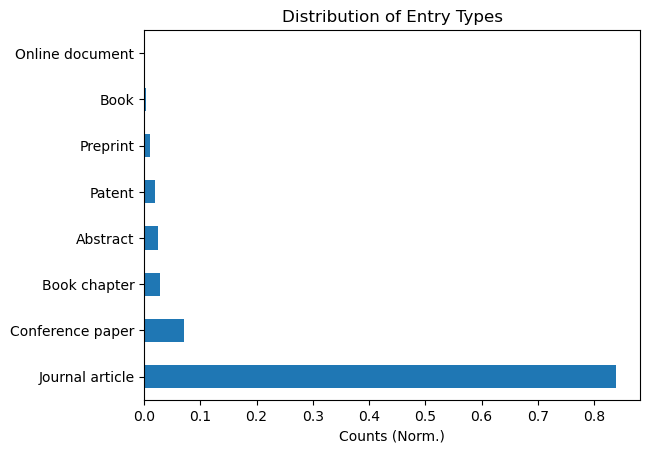

In [23]:
papers_df['Type'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Entry Types')

It looks like over 80% of the entries are with non-null types are categorized as `Journal Article`. Let's isolate the data set to only have journal articles.

In [24]:
idx = papers_df[papers_df['Type'] != 'Journal article'].index
papers_df = papers_df.drop(idx).reset_index(drop = 'True')

Let's check the amount of remaining entires.

In [25]:
print(f'There are {papers_df.shape[0]} entires remaining in the papers_df')

There are 24880 entires remaining in the papers_df


We still have over 20,000 entries which is a healthy amount of entries.

Let's look at the distribution of remaining null values.

In [26]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Year              0.000482
Source            0.000040
Cites             0.000000
Authors           0.000000
Title             0.000000
Type              0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

Let's check the null value distribution.

In [27]:
papers_df.isna().sum()

Cites              0
Authors            0
Title              0
Year              12
Source             1
Type               0
CitesPerYear       0
CitesPerAuthor     0
AuthorCount        0
query_id           0
dtype: int64

There are still null values in the `Year` and `Source` column, though they contain about 0.1% and 0.005% of the entries, respectively. Based on previous analysis of entires with null values, these entries are likely miscellaneous entry types that were inccorrectly categorized as journal articles, conference papers or books. Therefore, let's remove those entries with null values for `Year`.

In [28]:
papers_df = papers_df.dropna(subset = ['Year', 'Source']).reset_index(drop = 'True')

In [29]:
print(f'There are {papers_df.shape[0]} entires remaining in the papers_df')

There are 24867 entires remaining in the papers_df


We still have a healthy number of entries at over 24,000. Let's check to see if there are any remaining null values.

In [30]:
papers_df.isna().sum()

Cites             0
Authors           0
Title             0
Year              0
Source            0
Type              0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
dtype: int64

Hurray! There are zero remaining null values for `papers_df`. Let's save this version of the data set into a pickle.

In [31]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part2.pkl")

### Conclusion

We successfully removed all the null values in the `papers_df` to create a data frame of *publication* entires. Though a handful of individual cases accounted for about 30 entries will null values in the `Source` column, most of the null values were removed by deleting duplicated entires for `Title`, only including entires with `Types` values `Journal article`, `Conference paper` and `Book`, and removing columns that had over 99% of the entires as null, and removing columns such as `Volume`, `StartPage`, `EndPage` and `Issue` since it just includes additional citation information that can be used to find the journal entry, and not information that could rank of the citation entry.

## Part 3: Assigning Appropriate Data Types to `papers_df`

Let's look at the data types assigned to the columns in `papers_df` and see if any can be changed to better reflect the data in the column.

In [32]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int64  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  float64
 4   Source          24867 non-null  object 
 5   Type            24867 non-null  object 
 6   CitesPerYear    24867 non-null  float64
 7   CitesPerAuthor  24867 non-null  int64  
 8   AuthorCount     24867 non-null  int64  
 9   query_id        24867 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 1.9+ MB


The two most obvious columns where the data type can be changed is `Year` thats currently set to a non-numeric data type and `query_id` which is set to a `float` data type. Let's first change `Year` to a numeric data type `int16` since the year should only have 4 digits. 

In [38]:
num_cols = papers_df.select_dtypes('number').drop(['CitesPerAuthor', 'CitesPerYear'],axis = 1).columns

for col in num_cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    if max_val < 32E6:
        print(f'The type for {col} is being changed to int16')
        papers_df[col] = papers_df[col].astype('int16')
    print('\n')

The max value in the Cites column is 9210
The type for Cites is being changed to int16


The max value in the Year column is 2023
The type for Year is being changed to int16


The max value in the AuthorCount column is 12
The type for AuthorCount is being changed to int16


The max value in the query_id column is 615
The type for query_id is being changed to int16




In [39]:
cols = ['CitesPerYear', 'CitesPerAuthor']

for col in cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    if max_val < 32E6:
            print(f'The type for {col} is being changed to float16')
            papers_df[col] = papers_df[col].astype('float16')

The max value in the CitesPerYear column is 921.0
The type for CitesPerYear is being changed to float16
The max value in the CitesPerAuthor column is 2400
The type for CitesPerAuthor is being changed to float16


In [40]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int16  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  int16  
 4   Source          24867 non-null  object 
 5   Type            24867 non-null  object 
 6   CitesPerYear    24867 non-null  float16
 7   CitesPerAuthor  24867 non-null  float16
 8   AuthorCount     24867 non-null  int16  
 9   query_id        24867 non-null  int16  
dtypes: float16(2), int16(4), object(4)
memory usage: 1.0+ MB


All other columns look fine for now, though data types can always be changed later if needed. Let's save this state of the `papers_df` as a pickle.

In [41]:
papers_df.to_pickle(r"2023-03-20_NB1_papers_df_part3.pkl")

## Part 4 Preliminary Author Name Cleaning

In [42]:
papers_df['Authors'] = papers_df['Authors'].str.strip()
papers_df['Authors'] = papers_df['Authors'].str.rsplit(',')

In [43]:
auth_df = pd.DataFrame([np.asarray(i) for i in papers_df['Authors'].values])
display(auth_df)

,0,1,2,3,4,5,6,7,8,9,10,11
0,D Shi,V Adinolfi,R Comin,M Yuan,E Alarousu,A Buin,Y Chen,...,None,None,None,None
1,K Lin,J Xing,LN Quan,FPG de Arquer,X Gong,J Lu,L Xie,W Zhao,...,None,None,None
2,SA McDonald,G Konstantatos,S Zhang,PW Cyr,EJD Klem,L Levina,...,None,None,None,None,None
3,H Tan,A Jain,O Voznyy,X Lan,FP García de Arquer,JZ Fan,...,None,None,None,None,None
4,G Konstantatos,I Howard,A Fischer,S Hoogland,J Clifford,E Klem,...,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
24862,Y Shin,S Cho,S Han,GY Jung,None,None,None,None,None,None,None,None
24863,C Liu,Y Yang,K Rakstys,A Mahata,M Franckevicius,E Mosconi,...,None,None,None,None,None
24864,S Driukas,D Rutkauskas,M Franckevičius,J Chmeliov,V Gulbinas,None,None,None,None,None,None,None
24865,M Faizan,KC Bhamu,G Murtaza,X He,N Kulhari,MM AL‐Anazy,...,None,None,None,None,None


In [44]:
auth_df = auth_df.iloc[:, :3]
auth_df.columns = ['first_auth', 'second_auth', 'third_auth']

In [45]:
display(auth_df)

,first_auth,second_auth,third_auth
0,D Shi,V Adinolfi,R Comin
1,K Lin,J Xing,LN Quan
2,SA McDonald,G Konstantatos,S Zhang
3,H Tan,A Jain,O Voznyy
4,G Konstantatos,I Howard,A Fischer
...,...,...,...
24862,Y Shin,S Cho,S Han
24863,C Liu,Y Yang,K Rakstys
24864,S Driukas,D Rutkauskas,M Franckevičius
24865,M Faizan,KC Bhamu,G Murtaza


Let's append this data frame to `papers_df` and drop the `Authors` column.

In [46]:
papers_df = pd.concat([auth_df, papers_df.drop('Authors', axis = 1)], axis = 1)

Here is the new `papers_df` let's save it as a pickle.`

In [47]:
papers_df.sample(5)

,first_auth,second_auth,third_auth,Cites,Title,Year,Source,Type,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
7134,M Korkusinski,O Voznyy,P Hawrylak,102,Fine structure and size dependence of exciton ...,2010,Physical Review B,Journal article,7.851562,34.0,3,26
23175,K Wang,L Jin,Y Gao,42,Lead-free organic–perovskite hybrid quantum we...,2021,ACS nano,Journal article,21.000000,5.0,9,403
21798,TS Lee,YHL Lin,H Kim,67,Triplet energy transfer governs the dissociati...,2018,The Journal of Physical Chemistry Letters,Journal article,13.398438,11.0,6,321
4540,Y Firdaus,LP Maffei,F Cruciani,77,Polymer Main‐Chain Substitution Effects on the...,2017,Advanced Energy Materials,Journal article,12.828125,10.0,8,14
22629,SS Yadava,L Singh,S Sharma,17,Effect of temperature on the dielectric and fe...,2016,RSC Advances,Journal article,2.429688,3.0,5,367


In [48]:
papers_df.to_pickle('2023-03-24_NB1_papers_df_part4.pkl')

In [49]:
import re

def edit_names(name):
    
    if isinstance(name, str):
        # remove any non-UTF-8 characters using encode method
        name = name.encode('ascii', 'ignore').decode('ascii')
        
        # remove any parenthess, hyphans and periodsusing regenx
        name = re.sub(r'[^a-zA-Z\s]', '', name).strip()

        # remove double spaces
        name = re.sub(r'  ', '', name).strip()

        # Use re to remove commas and anything after them
        name = re.sub(r'\,.*', '', name).strip()

        # Use re to remove title: Dr
        name = re.sub(r'^Dr\.?\s*', '', name).strip()

        # Use re to remove title: phd
        name = re.sub(r'^PhD\s*', '', name).strip()

        # Use re to remove phd
        name = re.sub(r'Ph\.?D\.?.*', '', name).strip()

        # Use re to remove title: Proff.
        name = re.sub(r'^PROFF\.?\s*', '', name).strip()

        # Remove the title: 'jr'
        name = re.sub(r'jr\.?s*', '', name).strip()

        # Rmove the title 'Junior'
        name = re.sub(r'junior', '', name).strip()

        # Remove 'equal contribution'
        name = re.sub(r'equal contribution', '', name).strip()

        # Remove 'ltslmw'
        name = re.sub(r'lts', '', name).strip()

        # Remove 'lmw'
        name = re.sub(r'lmw', '', name).strip()

        # Remove 'orcid'
        name = re.sub(r'ORCID:0000000160401920', '', name).strip()
        
        # remove '= equal first authors'
        name = re.sub(r' equal first authors', '', name).strip()
        
        if name != '':
            return name.lower().strip()
        else:
            return None
    else:
        return None

def edit_papers_names(row):
    return [edit_names(i) for i in row]

def edit_query_names(row):
    split_col = [i.strip() for i in row['Query'].rsplit(' - ')]
    name = split_col[0]
    ret_val = edit_names(name)
    return ret_val

In [50]:
query_df = query_df.assign(query_author = query_df.apply(edit_query_names, axis = 1))

In [51]:
query_df.sample(3)

,id,Query,Source,Papers,Citations,Years,Cites_Year,Cites_Paper,Cites_Author,Papers_Author,...,star_count,year_first,year_last,ECC,acc1,acc2,acc5,acc20,hA,query_author
487,487,Rachel Beal - Stanford University,Google Scholar Profile,11,1802,10,180.20,163.82,266.29,2.50,...,4,2013,2021,1802,6,5,4,4,5,rachel beal
178,178,Ibrahim Dursun - Cornell University,Google Scholar Profile,49,7711,8,963.88,157.37,1132.11,8.56,...,24,2015,2022,7711,32,31,27,15,17,ibrahim dursun
360,360,"Ghada H. Ahmed - Postdoctoral Scholar, Stanfor...",Google Scholar Profile,21,1390,8,173.75,66.19,211.48,3.38,...,8,2015,2022,1390,17,16,12,5,8,ghada h ahmed


In [52]:
result = query_df['query_author'].value_counts().sum() == query_df['Query'].value_counts().sum()
print('Are the number of unqiue Queries maintained?\t', result)

Are the number of unqiue Queries maintained?	 True


In [53]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']] = papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].apply(edit_papers_names)

In [54]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].sample(3)

,first_auth,second_auth,third_auth
21622,i guilhon,lk teles,m marques
14607,j villalobos,dm morales,d antipin
16989,p wu,t he,h zhu


In [55]:
idx = papers_df[papers_df['third_auth'].isna()].index
papers_df = papers_df.drop(idx)

In [56]:
uni_auth = np.unique(np.concatenate(np.asarray(papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']])))

In [57]:
pd.Series(uni_auth).value_counts().sort_values()

a a petrov       1
a alfonsov       1
a agresti        1
a abascalsaiz    1
a abate          1
                ..
zv popovic       1
zv popovi        1
zv marinkovi     1
zy chen          1
zz ma            1
Length: 17694, dtype: int64

In [58]:
papers_df.isna().sum()

first_auth        0
second_auth       0
third_auth        0
Cites             0
Title             0
Year              0
Source            0
Type              0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
dtype: int64

In [59]:
papers_df.isna().sum()

first_auth        0
second_auth       0
third_auth        0
Cites             0
Title             0
Year              0
Source            0
Type              0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
dtype: int64

First, let's remove all redundent publications.

In [60]:
papers_df['Title'].value_counts().count()

17820

In [61]:
papers_df['Title'] = papers_df['Title'].str.lower()

In [62]:
for i in papers_df.index:
    title = papers_df.loc[i, 'Title']
    if np.char.find(title, 'supporting information') != -1 \
        or np.char.find(title, 'reply to the comment') != -1 \
        or np.char.find(title, '{sub') != -1\
        or np.char.find(title, 'correction') != -1\
        or np.char.find(title, 'erratum') != -1:
        papers_df = papers_df.drop(i)

In [63]:
papers_df.shape

(23343, 12)

In [64]:
papers_df['Title'].value_counts().count()

17578

In [65]:
papers_df['Title'] = papers_df['Title'].str.replace(r'[^a-zA-Z\s]', '', regex = True)

In [66]:
papers_df['Title'].value_counts().count()

17551

In [67]:
papers_df.shape

(23343, 12)

Make a `join_df`

In [68]:
join_df = pd.merge(left = papers_df, right = query_df[['id', 'query_author']], left_on = 'query_id', right_on = 'id')

In [69]:
join_df.head()

,first_auth,second_auth,third_auth,Cites,Title,Year,Source,Type,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,id,query_author
0,d shi,v adinolfi,r comin,4186,low trapstate density and long carrier diffusi...,2015,Science,Journal article,523.0000,523.0,8,0,0,edward sargent
1,k lin,j xing,ln quan,2319,perovskite lightemitting diodes with external ...,2018,Nature,Journal article,463.7500,258.0,9,0,0,edward sargent
2,sa mcdonald,g konstantatos,s zhang,2163,solutionprocessed pbs quantum dot infrared pho...,2005,Nature materials,Journal article,120.1875,309.0,7,0,0,edward sargent
3,h tan,a jain,o voznyy,1951,efficient and stable solutionprocessed planar ...,2017,Science,Journal article,325.2500,279.0,7,0,0,edward sargent
4,g konstantatos,i howard,a fischer,1897,ultrasensitive solutioncast quantum dot photod...,2006,Nature,Journal article,111.5625,271.0,7,0,0,edward sargent


In [70]:
result = papers_df.shape[0] == join_df.shape[0]
print('Are the number of rows maintained?\t', result)

Are the number of rows maintained?	 True


In [71]:
from difflib import SequenceMatcher

def custom_tokenizer(text):
    tokens = text.split()
    tokens = tokens[-1][-2:].lower()
    return tokens

def all_same(itemlist):
    '''
    Dermines if all the elements in a list are the same.
    
    '''
    return all(x == itemlist[0] for x in itemlist)

def get_unique_auth(df):
    
    author_list = np.concatenate(df.loc[:, ['first_auth', 'second_auth', 'third_auth']].values)
    auth_ser = pd.Series(author_list)
    
    og_names = auth_ser.unique().shape[0]
    print(f"There are {og_names} unique author names")
    return og_names

def get_token_tag(text):
    
    pass_letters =  ['x', 'y', 'z']
    pass_lastname = ['ee', 'ng', 'im', 'iu', 'an', 'on', 'ao', 'wu', 'hu']
    
    if isinstance(text, str):
        
        token = custom_tokenizer(text)
        if token not in pass_lastname and\
            text[0] not in pass_letters:
            return True
        else:
            return False
    
    elif isinstance(text, list):
        
        a, b = text

        token_a = custom_tokenizer(a)
        token_b = custom_tokenizer(b)
        
        if a != b and a[0] == b[0] and\
            a[0] not in pass_letters and\
            b[0] not in pass_letters and\
            token_a not in pass_lastname and\
            token_b not in pass_lastname:
            
            return True

        else:
            return False
        
def pull_name3(row, v, col = None, token_state = 'on', input_ratio = 0.90):
    
    '''
    For each title in the data set, check if there is more than one citation. If there is, check
    if the first authors names are formatted in the same way. If not, print the variation of the 
    name that is the longest.
    '''
    if v == 'v1':
        og_vals = row
    elif v == 'v2':
        og_vals = row[col].values
    
    #print(og_vals)
    new_vals = np.unique([i for i in og_vals if isinstance(i, str)])
    
    last_names = [i.rsplit(' ')[-1] for i in new_vals] # make a list of the last names
    first_initial = [i.rsplit(' ')[0][0] for i in new_vals] # make a list of the first initial
    
    if len(new_vals) > 1:
        
        replace_dic = {}
        
        if all_same(new_vals) == False:
            
            for i in range(0, len(new_vals)):
                    
                for j in range(i+1, len(new_vals)):
                        
                    a = new_vals[i]
                    b = new_vals[j]
                    
                    first_a, last_a = first_initial[i], last_names[i]
                    first_b, last_b = first_initial[j], last_names[j]
                            
                    ## These are letters that many asian names that would be considered > 80% similar by the seqeunce matcher would start with, but the names are meant to be different
                    
                    if token_state == 'on':
                        token_tag = get_token_tag([a,b])
                        ratio_tag = True
                    elif token_state == 'off':
                        token_tag = True
                        ratio_tag = False
                        
                    if token_tag == True:
                        
                        # If both names share the same last name and first inital
                        if last_a == last_b and first_a == first_b:
                            
                            name = [a,b]
                            name.sort(reverse = False, key = len)
                            replace_dic.update({name[0] : name[1]})
                    
                        else:
                            
                            if ratio_tag == True:
                            
                                r = SequenceMatcher(None, a, b).ratio()

                                if r > input_ratio: # if the names are at least 85% similar

                                    name = [a,b]
                                    name.sort(reverse = False, key = len)
                                    replace_dic.update({name[0] : name[1]})
                    else:
                        pass
                        
        if len(replace_dic) != 0: #if replace_dic is not empty
            return replace_dic
        else:
            return False
    else:
        return False

In [72]:
### NEED TO ENSURE THAT THE QUERY COLUMN DOES NOT CHANGE ###

def row_wise(df):
    
    print('-- Comparing Names Row Wise --')
    
    ## 1. Initiate the Replacement Dictionary 
    replace_dic = {}

    # Loop over each author column
    name_arr = np.asarray(df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'query_author']])

    for i in tqdm(range(name_arr.shape[0])):
        return_vals = pull_name3(name_arr[i, :], v = 'v1', token_state = 'on', input_ratio = 0.80)
        if return_vals:
            replace_dic.update(return_vals)
    
    return replace_dic, 'Row Wise', '#0072b2'

def groupby_QueryAuthor(df):
    
    print('-- Comparing the names by query_author --')
    
    # 1. Initiate the Replacement Dictionary 
    replace_dic = {}
    
    for i in tqdm(['first_auth', 'second_auth', 'third_auth']):
        return_vals = df.groupby('query_author').apply(pull_name3, v = 'v2', col = i, input_ratio = 0.87).values
        for k in return_vals[return_vals != False]:
            replace_dic.update(k) 
            
    return replace_dic, 'Query Wise', '#d55e00'

In [73]:
new_join_df = join_df.copy()
j = 0

auth_cols = ['first_auth', 'second_auth', 'third_auth', 'query_author']
auth_subcols = ['first_auth', 'second_auth', 'third_auth']

plt_dic = {'num_auth': [], 'labels': [], 'colors': [], 'iteration': [], 'change_first':[], 'change_second': [], 'change_third': [], 'change_query': []}

num = get_unique_auth(join_df);
plt_dic['num_auth'].append(num)
plt_dic['labels'].append('Start')
plt_dic['colors'].append('#009e73')
plt_dic['iteration'].append(j)

for key in list(plt_dic.keys())[4:]:
    plt_dic[key].append(0)
    
while j < 5:
    
    print('\n')
    print(f'--- Performing Cycle {j+1} ---')
    print('\n')
    
    for func in [row_wise, groupby_QueryAuthor]:
        
        replace_dic, label, color = func(join_df)
        
        compare_join_df = join_df.copy()
        
        join_df.loc[:, auth_subcols] = join_df.replace(replace_dic).loc[:, auth_subcols]
        num = get_unique_auth(join_df);
        plt_dic['num_auth'].append(num)
        plt_dic['labels'].append(label)
        plt_dic['colors'].append(color)
        plt_dic['iteration'].append(j)
        
        
        # Calculting the change in author names by column
        check_df = compare_join_df.loc[:, auth_cols] == join_df.loc[:, auth_cols]
        changed_ser = check_df.count() - check_df.sum()
        ch_first, ch_second, ch_third, ch_query = changed_ser
        plt_dic['change_first'].append(ch_first)
        plt_dic['change_second'].append(ch_second)
        plt_dic['change_third'].append(ch_third)
        plt_dic['change_query'].append(ch_query)
        
        print('\n')
    
    j = j + 1

There are 17675 unique author names


--- Performing Cycle 1 ---


-- Comparing Names Row Wise --


  0%|          | 0/23343 [00:00<?, ?it/s]

There are 17551 unique author names


-- Comparing the names by query_author --


  0%|          | 0/3 [00:00<?, ?it/s]

There are 16975 unique author names




--- Performing Cycle 2 ---


-- Comparing Names Row Wise --


...

There are 16937 unique author names




--- Performing Cycle 5 ---


-- Comparing Names Row Wise --


  0%|          | 0/23343 [00:00<?, ?it/s]

There are 16937 unique author names


-- Comparing the names by query_author --


  0%|          | 0/3 [00:00<?, ?it/s]

There are 16937 unique author names




In [74]:
num_auth = np.asarray(plt_dic['num_auth'])
shift_arr = np.subtract(num_auth[:len(num_auth)-1], num_auth[1:]) # shifted the array to perform subtraction 
diff_arr = np.append(0, shift_arr)
plt_dic['repl_auth'] = diff_arr # the number of replaced author names for reach step

`repl_auth` = $\frac{\Delta \text{Number of Authors}}{\text{Iteration}}$

In [88]:
group_auth_df = pd.DataFrame(plt_dic)
group_auth_df

,num_auth,labels,colors,iteration,change_first,change_second,change_third,change_query,repl_auth
0,17675,Start,#009e73,0,0,0,0,0,0
1,17551,Row Wise,#0072b2,0,3316,3257,3042,0,124
2,16975,Query Wise,#d55e00,0,1367,1285,1195,0,576
3,16975,Row Wise,#0072b2,1,32,27,35,0,0
4,16946,Query Wise,#d55e00,1,154,166,164,0,29
5,16946,Row Wise,#0072b2,2,0,0,0,0,0
6,16938,Query Wise,#d55e00,2,44,34,62,0,8
7,16938,Row Wise,#0072b2,3,0,0,0,0,0
8,16937,Query Wise,#d55e00,3,1,0,0,0,1
9,16937,Row Wise,#0072b2,4,0,0,0,0,0


<AxesSubplot:ylabel='labels'>

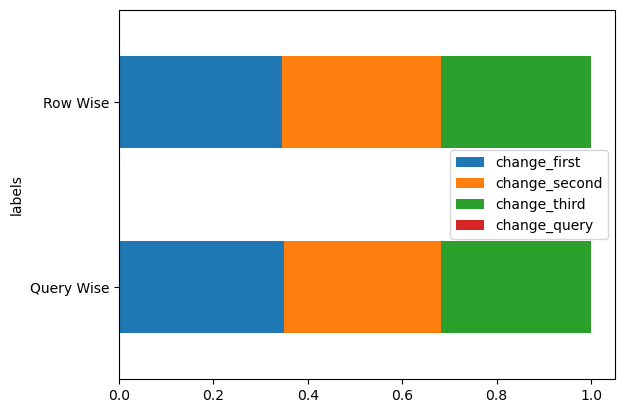

In [76]:
gp1 = group_auth_df[group_auth_df['labels'] != 'Start']
gp2 = gp1.groupby(['labels']).sum()[['change_first', 'change_second', 'change_third', 'change_query']]
ch_sum = np.sum(gp2.values, axis = 1)

per_df = pd.DataFrame(np.divide(gp2.values, ch_sum.reshape(-1, 1)), index = gp2.index, columns = gp2.columns)
per_df.plot.barh(stacked=True)

In [77]:
list(plt_dic.keys())[4:]

['change_first', 'change_second', 'change_third', 'change_query', 'repl_auth']

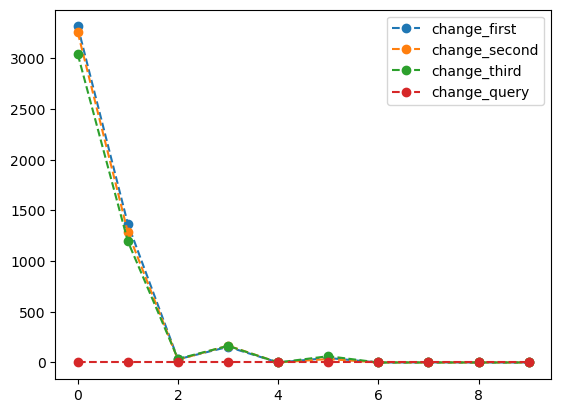

In [78]:
for key in list(plt_dic.keys())[4:8]:
    plt.plot(plt_dic[key][1:], marker = 'o', label = key, ls = 'dashed')
plt.legend()

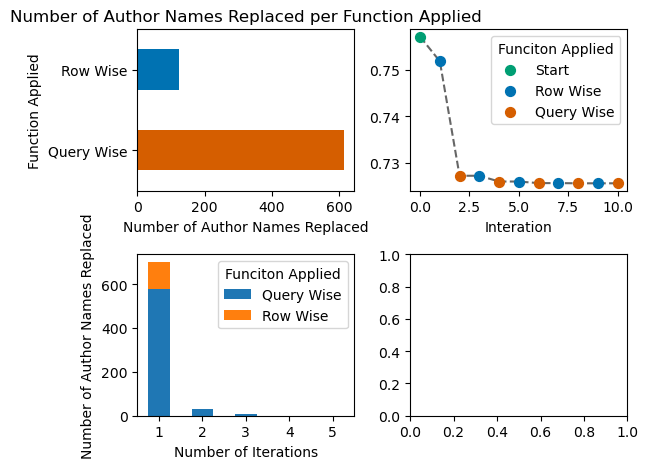

In [79]:
group_auth_df = group_auth_df[group_auth_df['labels'] != 'Start']

fig, axes = plt.subplots(2, 2)

ax = axes[0,0]
colors = group_auth_df.groupby('labels')['colors'].apply(list).str[0].values.tolist()
bar_plot = group_auth_df.groupby('labels')['repl_auth'].sum().plot(kind = 'barh', color = colors, ax = ax)

bar_plot.set_title('Number of Author Names Replaced per Function Applied')
bar_plot.set_xlabel('Number of Author Names Replaced')
bar_plot.set_ylabel('Function Applied')


ax = axes[0,1]
colors = plt_dic['colors']
num_authors = plt_dic['num_auth']
labels = plt_dic['labels']

# The average number of unique authors per citation
uni_auth_per_cit = np.divide(num_authors, join_df.shape[0])

for i in range(len(num_authors)):
    ax.scatter(i, uni_auth_per_cit[i], label = labels[i], color = colors[i], marker = 'o', s = 50)

ax.plot(uni_auth_per_cit, color = 'black', ls = 'dashed', zorder = 0, alpha = 0.6)
ax.set_xlabel('Interation')

container, label = ax.get_legend_handles_labels()
ax.legend(container[:3], label[:3], title = 'Funciton Applied', )

##############

ax = axes[1,0]
group_int_lab = group_auth_df.groupby(['iteration', 'labels']).sum().unstack()['repl_auth']
stacked_plot = group_int_lab.plot.bar(stacked=True,ax = ax)

x_ticks = np.unique(plt_dic['iteration'])
x_tick_labels = np.unique(plt_dic['iteration']) + 1
stacked_plot.set_xticks(x_ticks, x_tick_labels, rotation = 0);
stacked_plot.set_xlabel('Number of Iterations')
stacked_plot.set_ylabel('Number of Author Names Replaced')
stacked_plot.legend(title = 'Funciton Applied')


fig.tight_layout()

In [89]:
pd.DataFrame(plt_dic).to_pickle('2023-03-27_NB1_plt_df_part4.pkl')

Dropping rows with duplicated title names

In [80]:
join_df = join_df.drop_duplicates('Title')
get_unique_auth(join_df);

There are 16871 unique author names


In [81]:
papers_df = join_df.reset_index(drop = True)

In [82]:
papers_df = papers_df.drop('id', axis = 1)

In [83]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17551 entries, 0 to 17550
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      17551 non-null  object 
 1   second_auth     17551 non-null  object 
 2   third_auth      17551 non-null  object 
 3   Cites           17551 non-null  int16  
 4   Title           17551 non-null  object 
 5   Year            17551 non-null  int16  
 6   Source          17551 non-null  object 
 7   Type            17551 non-null  object 
 8   CitesPerYear    17551 non-null  float16
 9   CitesPerAuthor  17551 non-null  float16
 10  AuthorCount     17551 non-null  int16  
 11  query_id        17551 non-null  int16  
 12  query_author    17551 non-null  object 
dtypes: float16(2), int16(4), object(7)
memory usage: 1.1+ MB


In [86]:
papers_df.to_pickle('2023-03-27_NB1_papers_df_part4.pkl')

---